<a href="https://colab.research.google.com/github/esprydi/sentimen-analisis-shopee-playstore/blob/master/Sentiment_Analisis_shopee_Playstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-play-scraper

# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#Scraping Dataset

In [2]:
#mengimpor pustaka google_play_scrapper

from google_play_scraper import app, reviews_all, Sort

# Mengambil semua ulasan dari aplikasi
scrapreview = reviews(
    'com.shopee.id',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=20000
)

In [3]:
# Menyimpan ulasan dalam file CSV
import csv

with open('ulasan_shopee_app.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['review'])
    for review in scrapreview[0]: # Access the first element of the tuple which contains the list of reviews
        writer.writerow([review['content']])

# Loading Dataset

In [4]:
app_reviews_df = pd.DataFrame(scrapreview[0])
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('shopee_app_reviews.csv', index=None, header=True)

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview[0])

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

# Menampilkan hasil
print(f"Jumlah ulasan: {jumlah_ulasan}")
print

Jumlah ulasan: 20000


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [5]:
# Menampilkan lima baris pertama
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,675d7447-9df2-4eba-85b4-24660d842bb5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Asli keamanannya bagus, aman juga lancar semua...",5,2,3.68.42,2026-03-03 12:39:10,"Hi kak misterius_, makasih ya buat review bint...",2026-03-03 14:25:07,3.68.42
1,3bb0417f-8110-47ee-93ba-2ab82c463692,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,menurut ku aplikasi Shopee nya kurang menyenan...,1,2,3.68.37,2026-03-05 09:15:14,"Hai kak JK. Old 99, mohon maaf atas ketidaknya...",2026-03-05 10:45:12,3.68.37
2,2a4eee64-e5b0-4df2-a707-ddf826fbe28f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Makin hari, pelayanan expedisi kek 4nj!ng.. LE...",1,1,3.68.42,2026-03-08 17:58:12,"Hai kak ragil suhantoro, mohon maaf atas ketid...",2026-03-08 21:53:46,3.68.42
3,246efb4d-c63f-4c06-9b30-4fc8dcb8a0e0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,koneksinya padahal bagus tapi susah banget bua...,5,2,3.68.42,2026-03-06 03:37:59,"Hi Kak Misaki Yuki, maaf ya udah bikin Kakak g...",2026-03-06 06:50:38,3.68.42
4,2af7f7ea-0884-4807-a3c0-392a332547f0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya ini aplikasi sangat bagus, harga be...",4,1,3.68.42,2026-03-08 00:44:41,"Hi Kak Jasa Axel , Maaf ya untuk kendalanya. A...",2026-03-08 02:39:57,3.68.42


In [6]:
# Menampilkan informasi
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              20000 non-null  object        
 1   userName              20000 non-null  object        
 2   userImage             20000 non-null  object        
 3   content               20000 non-null  object        
 4   score                 20000 non-null  int64         
 5   thumbsUpCount         20000 non-null  int64         
 6   reviewCreatedVersion  19867 non-null  object        
 7   at                    20000 non-null  datetime64[ns]
 8   replyContent          18753 non-null  object        
 9   repliedAt             18753 non-null  datetime64[ns]
 10  appVersion            19867 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.7+ MB


In [7]:
# Membuat DataFrame baru dengan menghapus baris yang memiliki nilai yang hilang

clean_df = app_reviews_df.dropna()

In [8]:
# Menghapus baris duplikat
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan,jumlah_kolom = clean_df.shape

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18626 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              18626 non-null  object        
 1   userName              18626 non-null  object        
 2   userImage             18626 non-null  object        
 3   content               18626 non-null  object        
 4   score                 18626 non-null  int64         
 5   thumbsUpCount         18626 non-null  int64         
 6   reviewCreatedVersion  18626 non-null  object        
 7   at                    18626 non-null  datetime64[ns]
 8   replyContent          18626 non-null  object        
 9   repliedAt             18626 non-null  datetime64[ns]
 10  appVersion            18626 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.7+ MB


# Preprocessing Text

In [9]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text_tokens): # Menghapus stopwords dalam teks
    # Ambil stopwords dasar
    listStopwords = set(stopwords.words('indonesian'))
    # Tambahkan kata-kata sampah spesifik Shopee/Playstore
    listStopwords.update(['shopee', 'aplikasi', 'nya', 'sih', 'ke', 'di', 'dari', 'ya', 'loh', 'deh'])
    # Filter: Simpan kata jika TIDAK ada di listStopwords ATAU mengandung "_"
    filtered = [w for w in text_tokens if (w not in listStopwords) or ("_" in w)]

    return filtered # Mengembalikan list, bukan string

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

def reduce_lengthening(text): # Normalisasi karakter berulang misal : bagusss jadi bagus
    pattern = re.compile(r"(.)\1{2,}")
    return pattern.sub(r"\1\1", text)

def handle_negation(text): # Penanganan negasi misal "kurang bagus" kalau di pisah akan beda arti
    # Daftar Negasi
    negation_words = ["bukan", "tidak", "ga", "gak", "nggak", "tdk", "jangan", "kurang"]
    words = text.split()
    new_words = []
    i = 0
    while i < len(words):
        if words[i] in negation_words and i + 1 < len(words):
            # Gabungkan kata negasi dengan kata setelahnya
            # contoh : tidak puas jadi tidak_puas
            combined_word = words[i] + "_" + words[i + 1]
            new_words.append(combined_word)
            i += 2 # Loncat 2 kata
        else:
            new_words.append(words[i])
            i += 1
    return ' '.join(new_words)



In [10]:
slangwords = {"ga": "tidak", "gak": "tidak", "gakk": "tidak", "nggak": "tidak", "tdk": "tidak",
    "bgt": "banget", "bangettt": "banget", "skali": "sekali",
    "udah": "sudah", "udh": "sudah", "sdh": "sudah",
    "kalo": "kalau", "kl": "kalau", "klo": "kalau",
    "jd": "jadi", "jdi": "jadi",
    "kmrn": "kemarin", "skrg": "sekarang", "skr": "sekarang",
    "lemot": "lambat", "lola": "lambat",
    "ongkir": "ongkos kirim", "cod": "bayar di tempat",
    "bales": "balas", "admin": "petugas",
    "pas": "ketika", "tp": "tapi", "tapi": "tetapi"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = [slangwords[word] if word in slangwords else word for word in words]
    return ' '.join(fixed_words)


In [11]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

# 1. Membersihkan teks (Hapus simbol, URL, Angka)
clean_df['step1_clean'] = clean_df['content'].apply(cleaningText)

# 2. Case Folding (Kecilkan huruf)
clean_df['step2_fold'] = clean_df['step1_clean'].apply(casefoldingText)

# 3. Reduce Lengthening (Bagusss -> Baguss)
clean_df['step3_reduce'] = clean_df['step2_fold'].apply(reduce_lengthening)

# 4. Fix Slangwords (ga -> tidak)
# Note: Fungsi ini masih pakai .split() internal untuk memproses kata
clean_df['step4_slang'] = clean_df['step3_reduce'].apply(fix_slangwords)

# 5. Handle Negation (tidak bagus -> tidak_bagus)
clean_df['step5_negation'] = clean_df['step4_slang'].apply(handle_negation)

# 6. TOKENIZING (DI SINI TEMPATNYA)
# Memecah kalimat menjadi list kata yang bersih dan sudah terikat negasi
clean_df['step6_token'] = clean_df['step5_negation'].apply(tokenizingText)

# 7. Filtering (Hapus Stopwords dari LIST token)

clean_df['step7_filter'] = clean_df['step6_token'].apply(filteringText)
# 8. To Sentence (Kembalikan ke kalimat untuk dihitung skor leksikonnya)
clean_df['text_akhir'] = clean_df['step7_filter'].apply(toSentence)

display(clean_df[['content', 'text_akhir']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,content,text_akhir
0,"Asli keamanannya bagus, aman juga lancar semua...",asli keamanannya bagus aman lancar terkombinas...
1,menurut ku aplikasi Shopee nya kurang menyenan...,ku kurang_menyenangkan disaat bermain beduk vo...
2,"Makin hari, pelayanan expedisi kek 4nj!ng.. LE...",pelayanan expedisi kek njng lambat lelet gk se...
3,koneksinya padahal bagus tapi susah banget bua...,koneksinya bagus susah banget masuk lelet bang...
4,"Sebenarnya ini aplikasi sangat bagus, harga be...",bagus harga bersaing layanan bagus pengiriman ...


# Pelabelan

In [12]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# 1. SETUP MODEL & TOKENIZER
pretrained = "mdhugol/indonesia-bert-sentiment-classification"
model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

# Pastikan device=0 jika menggunakan GPU di Colab (Sangat disarankan untuk 10rb data)
device = 0 if torch.cuda.is_available() else -1
sentiment_analysis = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

# Index label sesuai dokumentasi
label_index = {'LABEL_0': 'Positive', 'LABEL_1': 'Neutral', 'LABEL_2': 'Negative'}

# --- 2. PROSES BATCH (PENGGANTI .APPLY) ---
print(f"Sedang memproses {len(clean_df)} data dengan Batch Processing...")

# Ubah kolom content menjadi list string (pastikan tidak ada nilai kosong/NaN)
list_texts = clean_df['content'].fillna("").astype(str).tolist()

# Jalankan pipeline langsung pada list
# batch_size: jumlah kalimat yang diproses sekaligus (sesuaikan dengan RAM GPU, 32 biasanya aman)
# truncation=True: memotong teks jika lebih dari 512 karakter (agar tidak error)
results = sentiment_analysis(list_texts, batch_size=32, truncation=True)

# --- 3. EKSTRAK HASIL KE DATAFRAME ---
# Kita simpan Labelnya dan juga Score (Confidence) dari IndoBERT
clean_df['sentiment'] = [label_index[res['label']] for res in results]
clean_df['confidence_score'] = [res['score'] for res in results] # Menyimpan angka keyakinan model

print("\nSelesai! Skor keyakinan IndoBERT telah disimpan di kolom 'confidence_score'.")
display(clean_df[['content', 'sentiment', 'confidence_score']].head())

# --- 4. CEK HASIL ---
print("\nDistribusi Sentimen (3 Kategori):")
print(clean_df['sentiment'].value_counts())
display(clean_df[['content', 'score', 'sentiment']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sedang memproses 18626 data dengan Batch Processing...

Selesai! Skor keyakinan IndoBERT telah disimpan di kolom 'confidence_score'.


,content,sentiment,confidence_score
0,"Asli keamanannya bagus, aman juga lancar semua...",Positive,0.449304
1,menurut ku aplikasi Shopee nya kurang menyenan...,Negative,0.960573
2,"Makin hari, pelayanan expedisi kek 4nj!ng.. LE...",Negative,0.704294
3,koneksinya padahal bagus tapi susah banget bua...,Negative,0.980220
4,"Sebenarnya ini aplikasi sangat bagus, harga be...",Negative,0.713094



Distribusi Sentimen (3 Kategori):
sentiment
Negative    10163
Positive     6430
Neutral      2033
Name: count, dtype: int64


,content,score,sentiment
0,"Asli keamanannya bagus, aman juga lancar semua...",5,Positive
1,menurut ku aplikasi Shopee nya kurang menyenan...,1,Negative
2,"Makin hari, pelayanan expedisi kek 4nj!ng.. LE...",1,Negative
3,koneksinya padahal bagus tapi susah banget bua...,5,Negative
4,"Sebenarnya ini aplikasi sangat bagus, harga be...",4,Negative


,count
sentiment,
Negative,10163
Positive,6430
Neutral,2033


/tmp/ipykernel_43222/1556481133.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


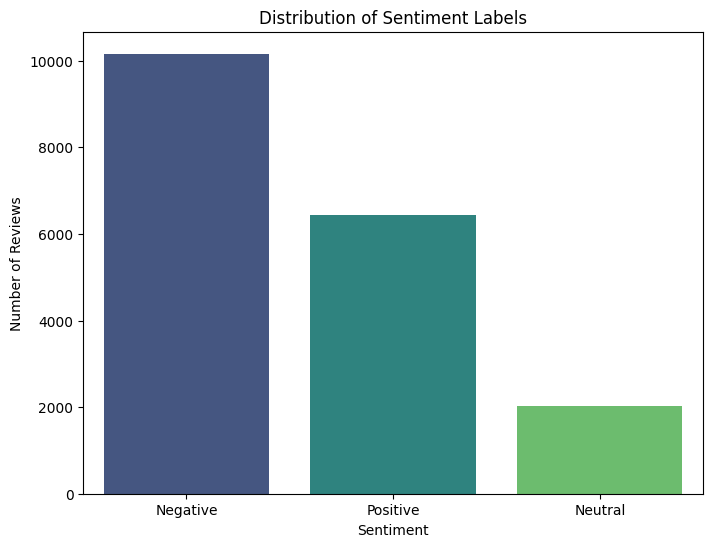

In [13]:
# Menghitung jumlah ulasan untuk setiap kategori sentimen
sentiment_counts = clean_df['sentiment'].value_counts()
display(sentiment_counts)

# Memvisualisasikan distribusi sentimen
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

#Eksplorasi Label

# Data Splitting dan Ekstraksi Fitur dengN TF-IDF

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF butuh teks dalam bentuk string tunggal
text_samples = clean_df['step7_filter'].apply(lambda x: ' '.join(x))

# Kita gunakan 300 fitur agar "apple-to-apple" dengan Word2Vec
tfidf_vectorizer = TfidfVectorizer(
    max_features=2000,      # Naikkan drastis dari 300
    ngram_range=(1, 2),     # Membaca "bagus" DAN "tidak bagus"
    min_df=2                # Abaikan kata yang muncul kurang dari 2 kali
)
X_tfidf = tfidf_vectorizer.fit_transform(text_samples).toarray()

# Get the IndoBERT confidence scores and reshape them
indobert_score = clean_df['confidence_score'].values.reshape(-1, 1)

# Gabungkan dengan skor IndoBERT
X_combined_tfidf = np.hstack((X_tfidf, indobert_score))

print("Skenario 2 Siap: TF-IDF (300) + IndoBERT Score (1) = 301 Fitur")

Skenario 2 Siap: TF-IDF (300) + IndoBERT Score (1) = 301 Fitur


#SMOTE TF-IDF

In [15]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Define the target variable 'y'
y = clean_df['sentiment']

# 1. Bagi data menjadi data Latih dan data Uji (WAJIB sebelum SMOTE)
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_combined_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Distribusi awal (Train TF-IDF): {Counter(y_train_tfidf)}")

Distribusi awal (Train TF-IDF): Counter({'Negative': 8130, 'Positive': 5144, 'Neutral': 1626})


In [16]:
from imblearn.over_sampling import SMOTE

# 2. Terapkan SMOTE pada data Latih (X_train) saja
# SMOTE akan membuat data Neutral "buatan" agar jumlahnya sama dengan Positive
smote_tfidf = SMOTE(random_state=42)
X_train_res_tfidf, y_train_res_tfidf = smote_tfidf.fit_resample(X_train_tfidf, y_train_tfidf)

print(f"Distribusi setelah SMOTE (Train TF-IDF): {Counter(y_train_res_tfidf)}")

Distribusi setelah SMOTE (Train TF-IDF): Counter({'Positive': 8130, 'Negative': 8130, 'Neutral': 8130})


### Membuat Fitur Word2Vec

Langkah ini akan menghasilkan representasi vektor untuk setiap ulasan menggunakan model Word2Vec yang dilatih dari data teks yang sudah dibersihkan.

In [17]:
!pip install gensim
from gensim.models import Word2Vec

# 1. Siapkan data untuk Word2Vec
# Kita akan menggunakan kolom 'step7_filter' yang berisi list kata-kata tokenized
word2vec_data = clean_df['step7_filter'].tolist()

# 2. Latih model Word2Vec
# vector_size: dimensi vektor (sesuai komentar 300 fitur)
# window: jarak maksimum antara kata target dan kata konteks
# min_count: mengabaikan semua kata dengan frekuensi total kurang dari ini
# workers: menggunakan jumlah core CPU untuk pelatihan (bisa disesuaikan)
print("Melatih model Word2Vec...")
model_w2v = Word2Vec(sentences=word2vec_data, vector_size=300, window=5, min_count=5, workers=4, seed=42)
print("Model Word2Vec berhasil dilatih.")

# 3. Fungsi untuk mendapatkan rata-rata vektor Word2Vec untuk sebuah dokumen (ulasan)
def document_vector(word_list, model):
    vectors = []
    for word in word_list:
        if word in model.wv:
            vectors.append(model.wv[word])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size) # Mengembalikan vektor nol jika tidak ada kata yang ditemukan

# 4. Terapkan fungsi untuk setiap ulasan untuk membuat fitur X_w2v
print("Membuat vektor dokumen (X_w2v)...")
X_w2v = np.array([document_vector(words, model_w2v) for words in word2vec_data])
print(f"X_w2v berhasil dibuat dengan bentuk: {X_w2v.shape}")

# Verifikasi bahwa X_w2v memiliki 300 fitur
print(f"Jumlah fitur Word2Vec (kolom X_w2v): {X_w2v.shape[1]}")

# Tampilkan 5 baris pertama dari X_w2v (opsional, untuk inspeksi)
# display(pd.DataFrame(X_w2v).head())


Melatih model Word2Vec...
Model Word2Vec berhasil dilatih.
Membuat vektor dokumen (X_w2v)...
X_w2v berhasil dibuat dengan bentuk: (18626, 300)
Jumlah fitur Word2Vec (kolom X_w2v): 300


In [18]:
import numpy as np

# A. Ambil fitur dari Word2Vec yang sudah kamu buat sebelumnya (300 kolom)
# Pastikan X_w2v sudah di-run kodenya
X_w2v_feature = X_w2v

# B. Ambil skor keyakinan IndoBERT sebagai fitur tambahan (1 kolom)
# Kita gunakan .reshape(-1, 1) agar bentuknya jadi satu kolom tegak
indobert_score_feature = clean_df['confidence_score'].values.reshape(-1, 1)

# C. GABUNGKAN (Total 301 Fitur)
X_combined_word2vec = np.hstack((X_w2v_feature, indobert_score_feature))

# D. Siapkan Target (Label yang mau ditebak)
y = clean_df['sentiment']

print("--- KONFIGURASI FINAL ---")
print(f"Total Baris Data: {X_combined_word2vec.shape[0]}")
print(f"Total Fitur (X): {X_combined_word2vec.shape[1]} (300 W2V + 1 IndoBERT Score)")
print(f"Target (y): Menggunakan label dari IndoBERT")

--- KONFIGURASI FINAL ---
Total Baris Data: 18626
Total Fitur (X): 301 (300 W2V + 1 IndoBERT Score)
Target (y): Menggunakan label dari IndoBERT


In [19]:
from sklearn.model_selection import train_test_split
from collections import Counter


# 1. Bagi data menjadi data Latih dan data Uji (WAJIB sebelum SMOTE)
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_combined_word2vec, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Distribusi awal (Train Word2Vec): {Counter(y_train_w2v)}")

Distribusi awal (Train Word2Vec): Counter({'Negative': 8130, 'Positive': 5144, 'Neutral': 1626})


In [20]:
from imblearn.over_sampling import SMOTE

# 2. Terapkan SMOTE pada data Latih (X_train) saja
# SMOTE akan membuat data Neutral "buatan" agar jumlahnya sama dengan Positive
smote = SMOTE(random_state=42)
X_train_res_word2vec, y_train_res_word2vec = smote.fit_resample(X_train_w2v, y_train_w2v)

print(f"Distribusi setelah SMOTE (Train Word2Vec): {Counter(y_train_res_word2vec)}")

Distribusi setelah SMOTE (Train Word2Vec): Counter({'Positive': 8130, 'Negative': 8130, 'Neutral': 8130})


# Modeling Menggunakan TF IDF

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded_tfidf = le.fit_transform(y_train_res_tfidf)
y_test_encoded_tfidf = le.transform(y_test_tfidf)

# Catatan:
# 0 biasanya Negative, 1 Neutral, 2 Positive (tergantung urutan abjad)
print("Urutan kelas:", le.classes_)

Urutan kelas: ['Negative' 'Neutral' 'Positive']


In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score # Added accuracy_score

# 1. Inisialisasi Model
xgb_model_tfidf = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,     # Belajar sangat detail
    max_depth=12,           # Pohon lebih dalam untuk menangkap pola Neutral
    gamma=0.2,                # Menambah regularisasi agar tidak overfit
    subsample=0.8,          # Mengambil 80% data secara acak agar tidak overfit
    colsample_bytree=0.7,   # Mengambil 80% fitur secara acak
    objective='multi:softprob', # Changed to binary:logistic for 2 classes
    num_class=3,
    random_state=42,
    n_jobs=-1
)

# 2. Training (Pakai data SMOTE yang sudah di-encode)
xgb_model_tfidf.fit(X_train_res_tfidf, y_train_encoded_tfidf)

# 3. Prediksi
y_pred_xgb_tfidf = xgb_model_tfidf.predict(X_test_tfidf) # Changed to X_test_tfidf

# 4. Evaluasi (Ubah kembali angka ke teks label asli)
print('XGBoost Accuracy:', accuracy_score(y_test_encoded_tfidf, y_pred_xgb_tfidf))
print(classification_report(y_test_encoded_tfidf, y_pred_xgb_tfidf, target_names=le.classes_))

XGBoost Accuracy: 0.808641975308642
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86      2033
     Neutral       0.42      0.43      0.42       407
    Positive       0.85      0.86      0.85      1286

    accuracy                           0.81      3726
   macro avg       0.71      0.71      0.71      3726
weighted avg       0.81      0.81      0.81      3726



In [23]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Inisialisasi Model
lgbm_model_tfidf = LGBMClassifier(
    n_estimators=1200,       # Tambah pohon agar belajar lebih lama
    learning_rate=0.03,      # Belajar lebih teliti
    num_leaves=150,          # Leaf-wise growth yang lebih kompleks (khas LightGBM)
    max_depth=12,            # Batasi kedalaman agar tidak overfit
    min_data_in_leaf=20,     # Mencegah pohon terlalu spesifik pada satu data
    feature_fraction=0.8,    # Random sampling fitur (mirip colsample di XGBoost)
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
    # class_weight='balanced' #DIHAPUS karena kita pakai data SMOTE
)

# 2. Training (WAJIB PAKAI HASIL SMOTE)
# Gunakan X_train_res dan y_train_encoded_res
lgbm_model_tfidf.fit(X_train_res_tfidf, y_train_encoded_tfidf)

# 3. Prediksi
y_pred_lgbm_tfidf = lgbm_model_tfidf.predict(X_test_tfidf)

# 4. Evaluasi
print('LightGBM Accuracy:', accuracy_score(y_test_encoded_tfidf, y_pred_lgbm_tfidf))
print("\nLaporan Klasifikasi LightGBM:")
print(classification_report(y_test_encoded_tfidf, y_pred_lgbm_tfidf, target_names=le.classes_))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Total Bins 84785
[LightGBM] [Info] Number of data points in the train set: 24390, number of used features: 1975
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
LightGBM Accuracy: 0.80703166935051

Laporan Klasifikasi LightGBM:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      2033
     Neutral       0.40      0.45      0.43       407
    Positive       0.86      0.85      0.85      1286

    accuracy                           0.81      3726
   macro avg       0.71      0.72      0.71      3726
weighted avg       0.81      0.81      0.81      3726



# Modeling Menggunakan Word2Vec

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded_word2vec = le.fit_transform(y_train_res_word2vec)
y_test_encoded_word2vec = le.transform(y_test_w2v)

# Catatan:
# 0 biasanya Negative, 1 Neutral, 2 Positive (tergantung urutan abjad)
print("Urutan kelas:", le.classes_)

Urutan kelas: ['Negative' 'Neutral' 'Positive']


In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score # Added accuracy_score

# 1. Inisialisasi Model
xgb_model_word2vec = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,     # Belajar sangat detail
    max_depth=12,           # Pohon lebih dalam untuk menangkap pola Neutral
    gamma=0.2,                # Menambah regularisasi agar tidak overfit
    subsample=0.8,          # Mengambil 80% data secara acak agar tidak overfit
    colsample_bytree=0.8,   # Mengambil 80% fitur secara acak
    objective='multi:softprob', # Changed to binary:logistic for 2 classes
    num_class=3,
    random_state=42,
    n_jobs=-1
)

# 2. Training (Pakai data SMOTE yang sudah di-encode)
xgb_model_word2vec.fit(X_train_res_word2vec, y_train_encoded_word2vec)

# 3. Prediksi
y_pred_xgb_word2vec = xgb_model_word2vec.predict(X_test_w2v) # Changed to X_test_w2v

# 4. Evaluasi (Ubah kembali angka ke teks label asli)
print('XGBoost Accuracy:', accuracy_score(y_test_encoded_word2vec, y_pred_xgb_word2vec))
print(classification_report(y_test_encoded_word2vec, y_pred_xgb_word2vec, target_names=le.classes_))

XGBoost Accuracy: 0.7962962962962963
              precision    recall  f1-score   support

    Negative       0.87      0.83      0.85      2033
     Neutral       0.37      0.45      0.41       407
    Positive       0.85      0.85      0.85      1286

    accuracy                           0.80      3726
   macro avg       0.70      0.71      0.70      3726
weighted avg       0.81      0.80      0.80      3726



In [26]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Inisialisasi Model
lgbm_model_word2vec = LGBMClassifier(
    n_estimators=1200,       # Tambah pohon agar belajar lebih lama
    learning_rate=0.03,      # Belajar lebih teliti
    num_leaves=150,          # Leaf-wise growth yang lebih kompleks (khas LightGBM)
    max_depth=12,            # Batasi kedalaman agar tidak overfit
    min_data_in_leaf=20,     # Mencegah pohon terlalu spesifik pada satu data
    feature_fraction=0.8,    # Random sampling fitur (mirip colsample di XGBoost)
    force_col_wise=True,
    random_state=42,
    n_jobs=-1,
    # class_weight='balanced' #DIHAPUS karena kita pakai data SMOTE
)

# 2. Training (WAJIB PAKAI HASIL SMOTE)
# Gunakan X_train_res dan y_train_encoded_res
lgbm_model_word2vec.fit(X_train_res_word2vec, y_train_encoded_word2vec)

# 3. Prediksi
y_pred_lgbm_word2vec = lgbm_model_word2vec.predict(X_test_w2v) # Changed to X_test_w2v

# 4. Evaluasi
print('LightGBM Accuracy:', accuracy_score(y_test_encoded_word2vec, y_pred_lgbm_word2vec))
print("\nLaporan Klasifikasi LightGBM:")
print(classification_report(y_test_encoded_word2vec, y_pred_lgbm_word2vec, target_names=le.classes_))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Total Bins 76755
[LightGBM] [Info] Number of data points in the train set: 24390, number of used features: 301
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
LightGBM Accuracy: 0.8040794417606012

Laporan Klasifikasi LightGBM:
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86      2033
     Neutral       0.39      0.42      0.41       407
    Positive       0.86      0.85      0.85      1286

    accuracy                           0.80      3726
   macro avg       0.70      0.71      0.71      3726
weighted avg       0.81      0.80      0.81      3726

